# Used Device Price Prediction
**Dataset:** https://www.kaggle.com/datasets/ahsan81/used-handheld-device-data


## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

## 2. Load & Explore

In [4]:
df = pd.read_csv('used_device_data.csv')
print(df.shape)
df.head()

(3454, 15)


,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [5]:
print(df.dtypes)
df.describe()

device_brand              object
os                        object
screen_size              float64
4g                        object
5g                        object
rear_camera_mp           float64
front_camera_mp          float64
internal_memory          float64
ram                      float64
battery                  float64
weight                   float64
release_year               int64
days_used                  int64
normalized_used_price    float64
normalized_new_price     float64
dtype: object


,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [6]:
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"Total missing: {df.isnull().sum().sum()}")

rear_camera_mp     179
front_camera_mp      2
internal_memory      4
ram                  4
battery              6
weight               7
dtype: int64
Total missing: 202


## 3. Visualizations

Five plots covering price distributions, feature correlations, variable distributions, scatter relationships, and categorical impact on price.

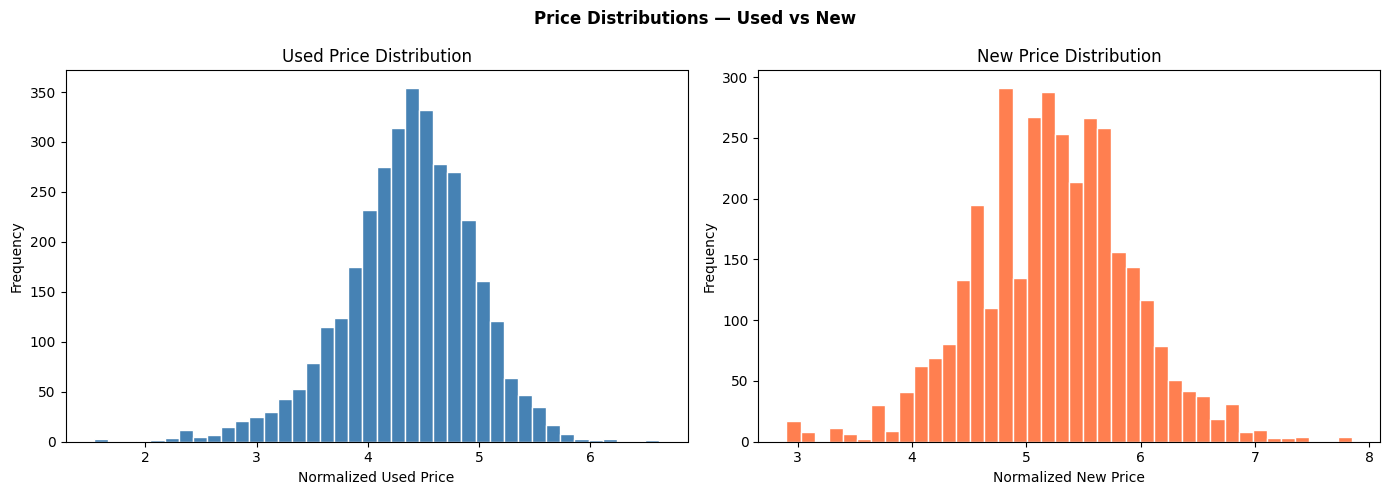

In [7]:
# Price distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['normalized_used_price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Used Price Distribution')
axes[0].set_xlabel('Normalized Used Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['normalized_new_price'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('New Price Distribution')
axes[1].set_xlabel('Normalized New Price')
axes[1].set_ylabel('Frequency')

plt.suptitle('Price Distributions — Used vs New', fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# Both distributions are right-skewed. Used prices cluster in a narrower range,
# suggesting resale values converge regardless of original cost.

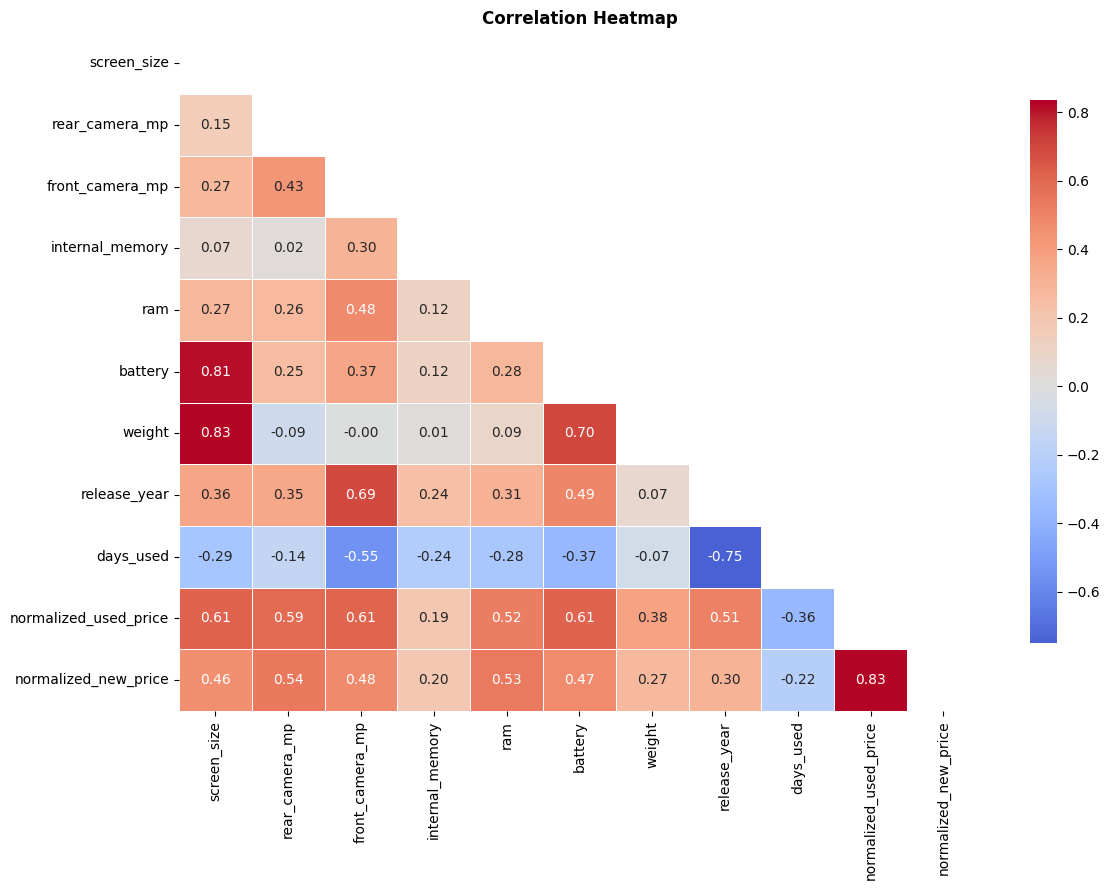

In [8]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# normalized_new_price has the strongest correlation (~0.85) with used price.
# RAM, internal_memory, and release_year also show meaningful positive correlations.

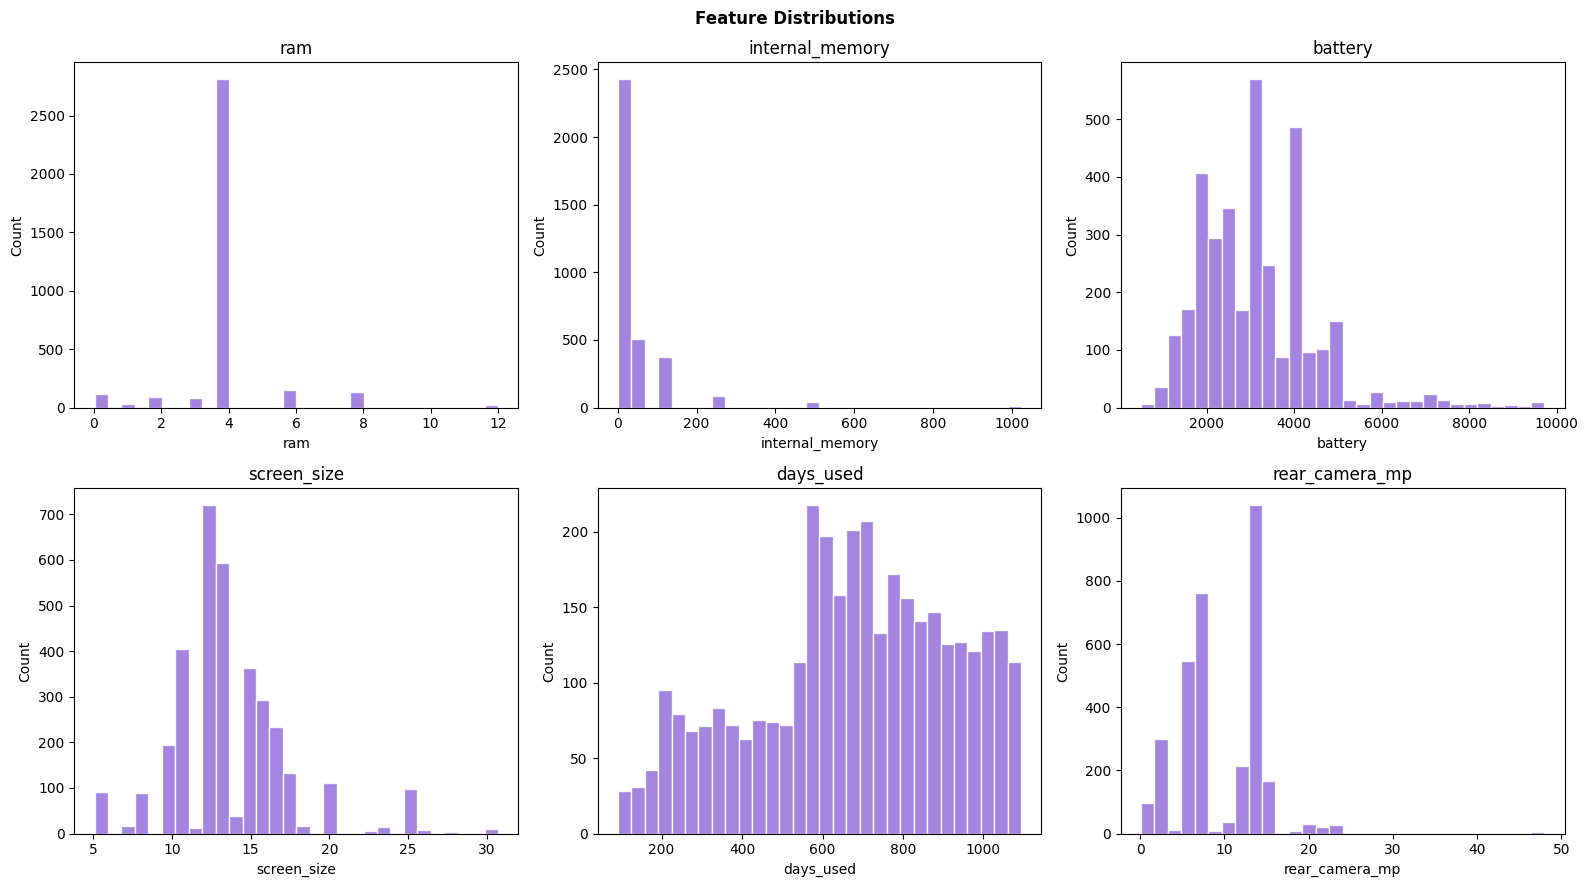

In [9]:
# Feature distributions
features_to_plot = ['ram', 'internal_memory', 'battery', 'screen_size', 'days_used', 'rear_camera_mp']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].hist(df[col], bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
# RAM and internal_memory are right-skewed — most devices are budget/mid-range.
# days_used spans a wide range; battery capacity mostly falls between 3000–5000 mAh.

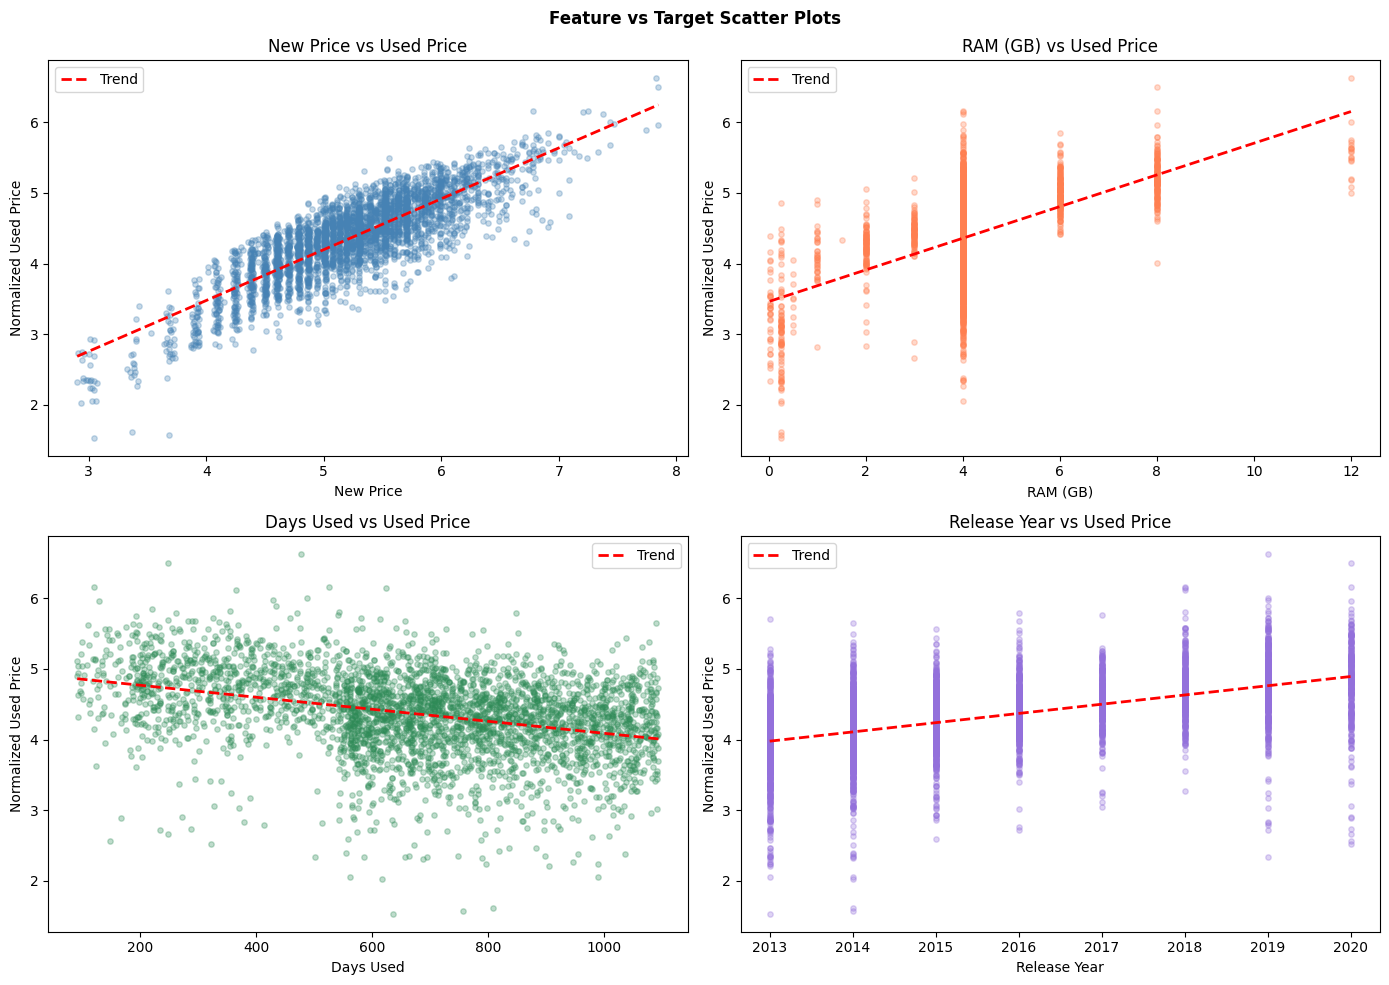

In [10]:
# Scatter plots: key features vs target
scatter_features = ['normalized_new_price', 'ram', 'days_used', 'release_year']
labels = ['New Price', 'RAM (GB)', 'Days Used', 'Release Year']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label, color) in enumerate(zip(scatter_features, labels, colors)):
    axes[i].scatter(df[feat], df['normalized_used_price'], alpha=0.3, s=15, color=color)
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'normalized_used_price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Normalized Used Price')
    axes[i].set_title(f'{label} vs Used Price')
    axes[i].legend()

plt.suptitle('Feature vs Target Scatter Plots', fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
# New price has a strong positive trend. RAM shows moderate correlation.
# Days used is slightly negative — older devices are worth less, as expected.

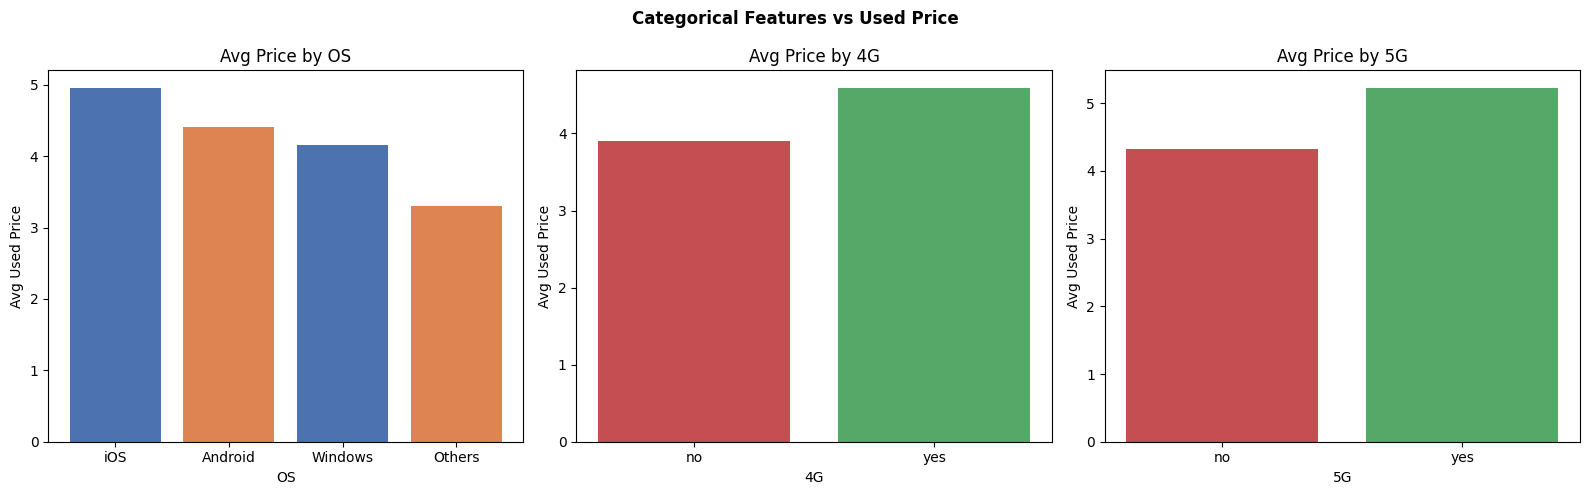

In [11]:
# Categorical impact on price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

os_prices = df.groupby('os')['normalized_used_price'].mean().sort_values(ascending=False)
axes[0].bar(os_prices.index, os_prices.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Avg Price by OS')
axes[0].set_xlabel('OS')
axes[0].set_ylabel('Avg Used Price')

g4_prices = df.groupby('4g')['normalized_used_price'].mean()
axes[1].bar(g4_prices.index, g4_prices.values, color=['#c44e52', '#55a868'])
axes[1].set_title('Avg Price by 4G')
axes[1].set_xlabel('4G')
axes[1].set_ylabel('Avg Used Price')

g5_prices = df.groupby('5g')['normalized_used_price'].mean()
axes[2].bar(g5_prices.index, g5_prices.values, color=['#c44e52', '#55a868'])
axes[2].set_title('Avg Price by 5G')
axes[2].set_xlabel('5G')
axes[2].set_ylabel('Avg Used Price')

plt.suptitle('Categorical Features vs Used Price', fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_categorical_impact.png', dpi=150, bbox_inches='tight')
plt.show()
# iOS devices hold significantly higher resale value than Android.
# 5G support also correlates with higher prices — relevant as 5G expands in Africa.

## 4. Feature Engineering & Preprocessing

- Encode `4g`, `5g` (yes/no → 1/0), `os` (Android/iOS → 0/1)
- One-hot encode `device_brand` (top 10 brands; rest → 'Other')
- Impute missing values with column median
- Standardize all numeric features
- Note: `normalized_new_price` is kept but flags a leakage risk in production

In [12]:
df_model = df.copy()

df_model['4g'] = df_model['4g'].map({'yes': 1, 'no': 0})
df_model['5g'] = df_model['5g'].map({'yes': 1, 'no': 0})
df_model['os'] = df_model['os'].map({'Android': 0, 'iOS': 1})

top_brands = df_model['device_brand'].value_counts().nlargest(10).index.tolist()
df_model['device_brand'] = df_model['device_brand'].apply(
    lambda x: x if x in top_brands else 'Other'
)
df_model = pd.get_dummies(df_model, columns=['device_brand'], drop_first=True)

bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

for col in df_model.select_dtypes(include=['float64', 'int64']).columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Missing after imputation: {df_model.isnull().sum().sum()}")

TARGET = 'normalized_used_price'
FEATURES = [col for col in df_model.columns if col != TARGET]
X = df_model[FEATURES]
y = df_model[TARGET]

print(f"X: {X.shape}, y: {y.shape}")

Missing after imputation: 0
X: (3454, 23), y: (3454,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 2763  |  Test: 691


In [14]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

print("Scaling done.")

Scaling done.


## 5. Model Training

In [15]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)

lr_train_loss = mean_squared_error(y_train, lr_train_pred)
lr_test_loss  = mean_squared_error(y_test, lr_test_pred)
lr_r2         = r2_score(y_test, lr_test_pred)

print(f"Linear Regression  |  Train MSE: {lr_train_loss:.4f}  |  Test MSE: {lr_test_loss:.4f}  |  R²: {lr_r2:.4f}")

Linear Regression  |  Train MSE: 0.0547  |  Test MSE: 0.0526  |  R²: 0.8378


In [16]:
# SGD (gradient descent) — used to produce the loss curve
train_losses_gd = []
test_losses_gd  = []
n_epochs = 100

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                         learning_rate='constant', eta0=0.01, tol=None)

X_train_arr = np.array(X_train_scaled)
X_test_arr  = np.array(X_test_scaled)
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

for epoch in range(n_epochs):
    sgd_model.fit(X_train_arr, y_train_arr)
    train_losses_gd.append(mean_squared_error(y_train_arr, sgd_model.predict(X_train_arr)))
    test_losses_gd.append(mean_squared_error(y_test_arr,  sgd_model.predict(X_test_arr)))

print(f"SGD final  |  Train MSE: {train_losses_gd[-1]:.4f}  |  Test MSE: {test_losses_gd[-1]:.4f}")

SGD final  |  Train MSE: 0.0643  |  Test MSE: 0.0606


In [17]:
# Decision Tree
tree_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)

tree_train_pred = tree_model.predict(X_train_scaled)
tree_test_pred  = tree_model.predict(X_test_scaled)

tree_train_loss = mean_squared_error(y_train, tree_train_pred)
tree_test_loss  = mean_squared_error(y_test, tree_test_pred)
tree_r2         = r2_score(y_test, tree_test_pred)

print(f"Decision Tree      |  Train MSE: {tree_train_loss:.4f}  |  Test MSE: {tree_test_loss:.4f}  |  R²: {tree_r2:.4f}")

Decision Tree      |  Train MSE: 0.0385  |  Test MSE: 0.0654  |  R²: 0.7986


In [18]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)

rf_train_loss = mean_squared_error(y_train, rf_train_pred)
rf_test_loss  = mean_squared_error(y_test, rf_test_pred)
rf_r2         = r2_score(y_test, rf_test_pred)

print(f"Random Forest      |  Train MSE: {rf_train_loss:.4f}  |  Test MSE: {rf_test_loss:.4f}  |  R²: {rf_r2:.4f}")

Random Forest      |  Train MSE: 0.0190  |  Test MSE: 0.0469  |  R²: 0.8556


## 6. Loss Curve

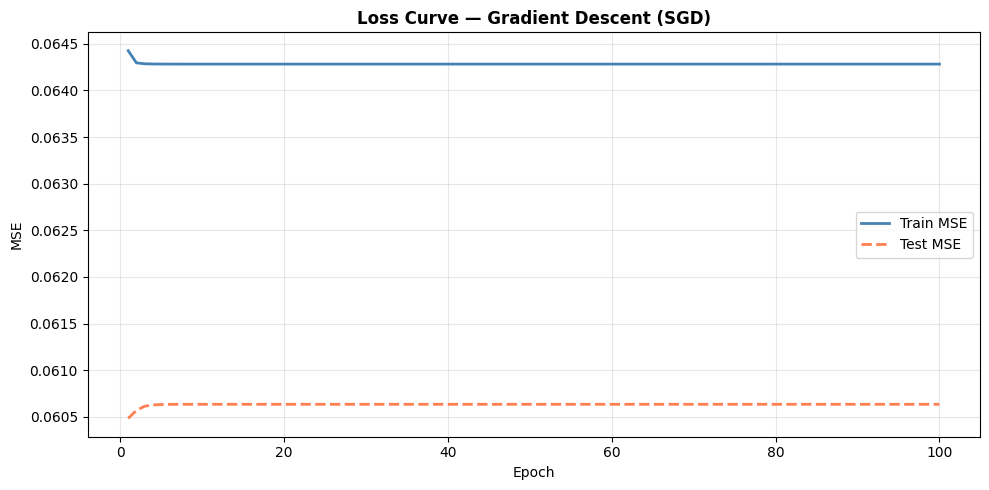

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses_gd, label='Train MSE', color='steelblue', linewidth=2)
plt.plot(range(1, n_epochs + 1), test_losses_gd,  label='Test MSE',  color='coral', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss Curve — Gradient Descent (SGD)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison & Scatter Plots

In [20]:
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [lr_train_loss, tree_train_loss, rf_train_loss],
    'Test MSE':  [lr_test_loss,  tree_test_loss,  rf_test_loss],
    'Test R²':   [lr_r2,         tree_r2,          rf_r2]
}).sort_values('Test MSE')

print(results.to_string(index=False))
best_model_name = results.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")

            Model  Train MSE  Test MSE  Test R²
    Random Forest   0.019010  0.046871 0.855566
Linear Regression   0.054746  0.052646 0.837773
    Decision Tree   0.038530  0.065353 0.798615

Best model: Random Forest


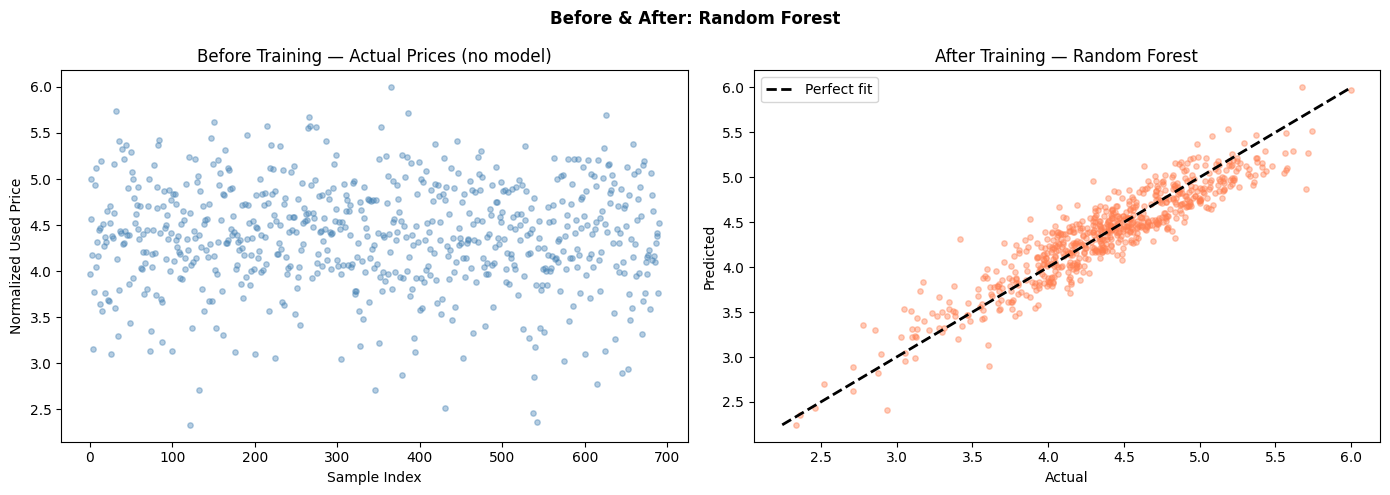

In [21]:
# Scatter — before & after: Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw actual prices (no model, no fit line)
axes[0].scatter(range(len(y_test)), y_test.values, alpha=0.4, s=15, color='steelblue')
axes[0].set_title('Before Training — Actual Prices (no model)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Normalized Used Price')

# After: predicted vs actual with perfect-fit line
min_val = min(y_test.min(), rf_test_pred.min())
max_val = max(y_test.max(), rf_test_pred.max())
axes[1].scatter(y_test.values, rf_test_pred, alpha=0.4, s=15, color='coral')
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect fit')
axes[1].set_title('After Training — Random Forest')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.suptitle('Before & After: Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


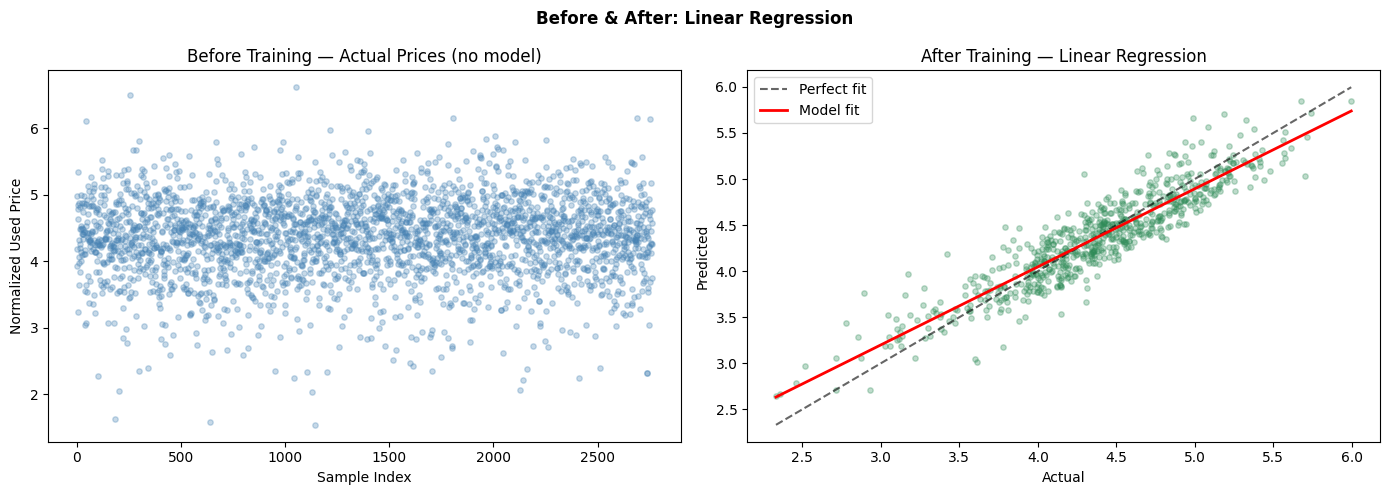

In [22]:
# Scatter — before & after: Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw actual prices (no model)
axes[0].scatter(range(len(y_train)), y_train.values, alpha=0.3, s=15, color='steelblue')
axes[0].set_title('Before Training — Actual Prices (no model)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Normalized Used Price')

# After: predicted vs actual with perfect-fit and regression lines
axes[1].scatter(y_test.values, lr_test_pred, alpha=0.3, s=15, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, alpha=0.6, label='Perfect fit')
z = np.polyfit(y_test.values, lr_test_pred, 1)
xs = np.linspace(y_test.min(), y_test.max(), 100)
axes[1].plot(xs, np.poly1d(z)(xs), 'r-', linewidth=2, label='Model fit')
axes[1].set_title('After Training — Linear Regression')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.suptitle('Before & After: Linear Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_lr_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save Models

In [23]:
for name, model in [('linear_regression_model', lr_model),
                    ('decision_tree_model', tree_model),
                    ('random_forest_model', rf_model),
                    ('scaler', scaler)]:
    with open(f'{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

best_test_mse = min(lr_test_loss, tree_test_loss, rf_test_loss)
if best_test_mse == rf_test_loss:
    best_model, best_name = rf_model, 'RandomForest'
elif best_test_mse == tree_test_loss:
    best_model, best_name = tree_model, 'DecisionTree'
else:
    best_model, best_name = lr_model, 'LinearRegression'

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved. Best model: {best_name} (Test MSE: {best_test_mse:.4f})")

Saved. Best model: RandomForest (Test MSE: 0.0469)


## 9. Prediction Script

In [24]:
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

sample_index  = 0
sample_raw    = X_test.iloc[[sample_index]]
sample_actual = y_test.iloc[sample_index]

sample_scaled = sample_raw.copy()
sample_scaled[numeric_features] = loaded_scaler.transform(sample_raw[numeric_features])

predicted_price = loaded_model.predict(np.array(sample_scaled))[0]

print(f"Model: {best_name}")
print(f"Actual:    {sample_actual:.4f}")
print(f"Predicted: {predicted_price:.4f}")
print(f"Error:     {abs(sample_actual - predicted_price):.4f}")

Model: RandomForest
Actual:    3.9742
Predicted: 4.0388
Error:     0.0646


In [25]:
# Manual prediction — Samsung-style Android, Kigali market
sample_device = pd.DataFrame([{
    'os': 0, 'screen_size': 16.5, '4g': 1, '5g': 0,
    'rear_camera_mp': 48, 'front_camera_mp': 16,
    'internal_memory': 128, 'ram': 6,
    'battery': 4000, 'weight': 190,
    'release_year': 2021, 'days_used': 365,
    'normalized_new_price': 5.2
}])

for col in X_train.columns:
    if col not in sample_device.columns:
        sample_device[col] = 0
sample_device = sample_device[X_train.columns]

sample_device_scaled = sample_device.copy()
sample_device_scaled[numeric_features] = loaded_scaler.transform(sample_device[numeric_features])

manual_pred = loaded_model.predict(np.array(sample_device_scaled))[0]
print(f"Device: Samsung-style Android | 128GB | 6GB RAM | 4G | 1 year used")
print(f"Predicted normalized used price: {manual_pred:.4f}")

Device: Samsung-style Android | 128GB | 6GB RAM | 4G | 1 year used
Predicted normalized used price: 4.8321


## 11. API metadata

After training and saving pickles, regenerate everything the FastAPI service needs by running **from this folder**:

`python3 training_pipeline.py` **or** `python3 export_model_metadata.py`

Both write `output/model_metadata.json`, `output/training_metrics.json` (for the **best** test-MSE model), `scaler.pkl`, per-model pickles, and `best_model.pkl` (loaded by default in the API).

## 10. Summary

| Model | Train MSE | Test MSE | Test R² |
|---|---|---|---|
| Linear Regression | 0.0547 | 0.0526 | 0.8378 |
| Decision Tree | 0.0385 | 0.0654 | 0.7986 |
| **Random Forest** | **0.0190** | **0.0469** | **0.8556** |

Random Forest gives the best results. `normalized_new_price` is the strongest single predictor, followed by 5G support, RAM, and release year. iOS devices hold noticeably higher resale value than Android across the dataset.


## 12. Keep `output/` in sync

The script [`training_pipeline.py`](training_pipeline.py) implements the same preprocessing and model training as this notebook and refreshes `output/` for deployment. Run it after you change the CSV or want to match CI/local API artifacts without re-running every notebook cell.